https://www.kdnuggets.com/5-powerful-python-decorators-to-optimize-llm-applications

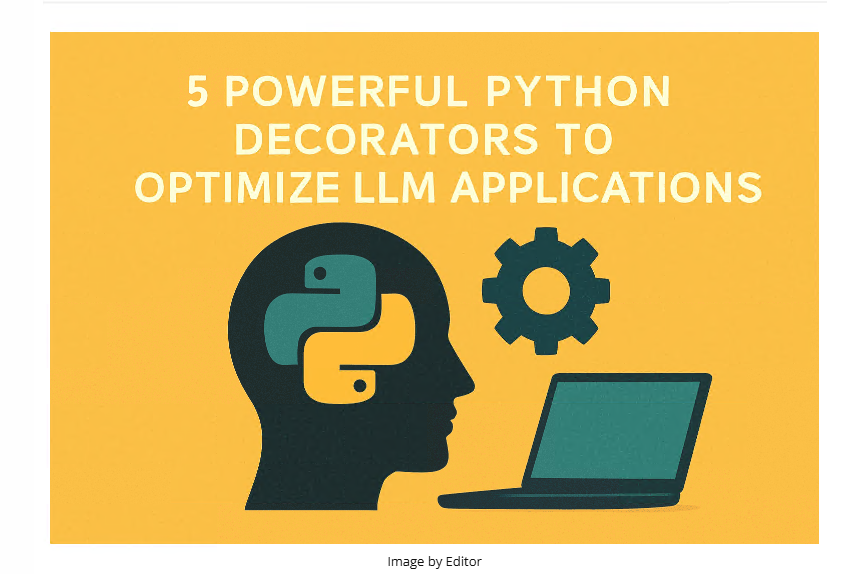

In [1]:
print("Hello")

Hello


In [2]:
!pip install functools

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for functools (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [91 lines of output]
      src/compose.c: In function ‘compose_dealloc’:
      src/compose.c:96:11: error: ‘struct compose’ has no member named ‘ob_type’
         96 |         co->ob_type->tp_free(co);
            |           ^~
      src/compose.c: In function ‘compose_repr’:
      src/compose.c:137:13: warning: implicit declaration of function ‘PyString_FromFormat’; did you mean ‘PyBytes_FromFormat’? [-Wimplicit-function-declaration]
        137 |         s = PyString_FromFormat("<composition on %s at %p>",
            |             ^~~~~~~~~~~~~~~~~~~
            |             PyBytes_FromFormat
      src/compose.c:138:13: warning: implicit declaration of function ‘PyString_AsString’ [-Wimplicit-function-declarat

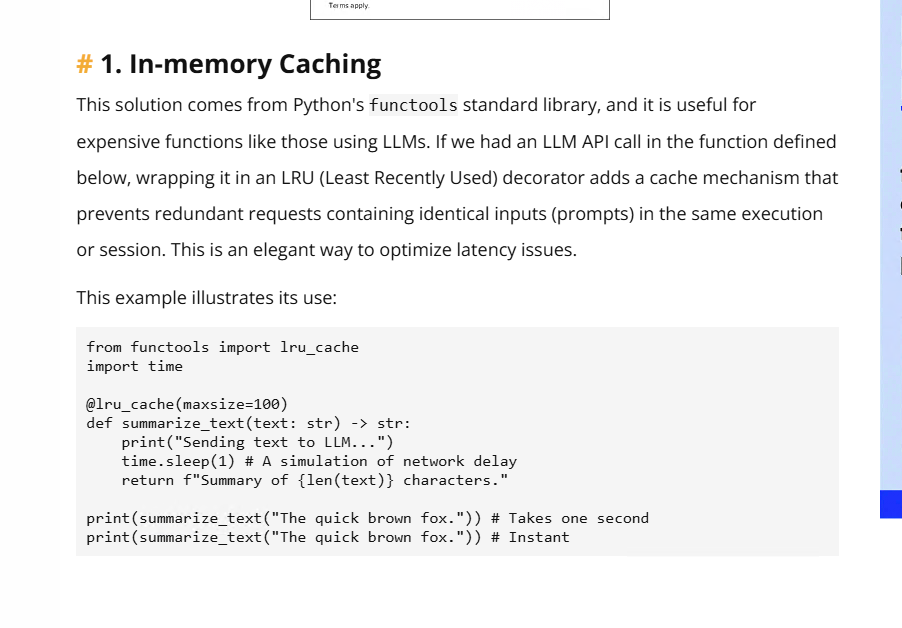

In [2]:
from functools import lru_cache
import time

@lru_cache(maxsize=100)
def summarize_text(text: str) -> str:
    print("Sending text to LLM...")
    time.sleep(1) # A simulation of network delay
    return f"Summary of {len(text)} characters."

print(summarize_text("The quick brown fox.")) # Takes one second
print(summarize_text("The quick brown fox.")) # Instant

Sending text to LLM...
Summary of 20 characters.
Summary of 20 characters.


In [3]:
from functools import lru_cache
import time

@lru_cache(maxsize=100)
def summarize_text(text: str) -> str:
    print("Sending text to LLM...")
    time.sleep(10) # A simulation of network delay
    return f"Summary of {len(text)} characters."

print(summarize_text("The quick brown fox.")) # Takes one second
print(summarize_text("The quick brown fox.")) # Instant

Sending text to LLM...
Summary of 20 characters.
Summary of 20 characters.


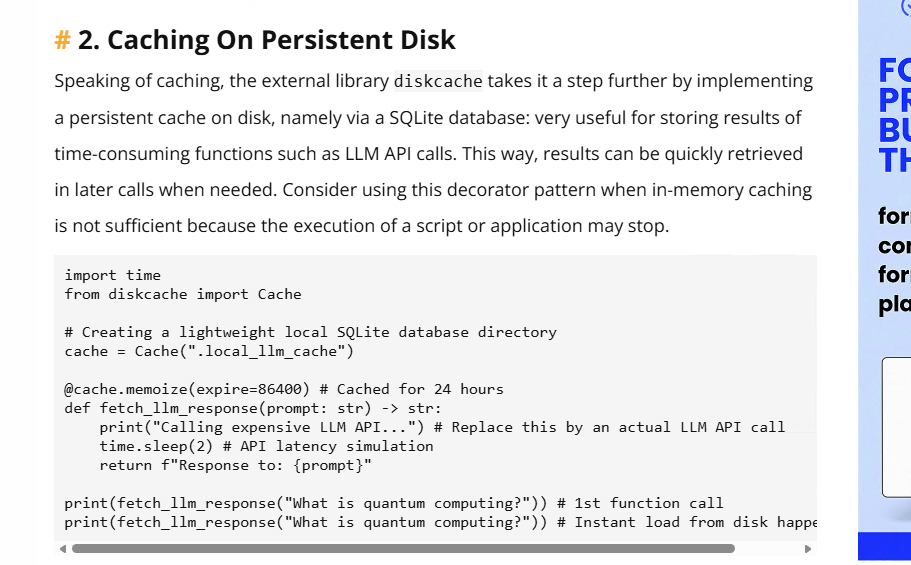

In [7]:
!pip install diskcache

In [8]:
import time
from diskcache import Cache

# Creating a lightweight local SQLite database directory
cache = Cache(".local_llm_cache")

@cache.memoize(expire=86400) # Cached for 24 hours
def fetch_llm_response(prompt: str) -> str:
    print("Calling expensive LLM API...") # Replace this by an actual LLM API call
    time.sleep(2) # API latency simulation
    return f"Response to: {prompt}"

print(fetch_llm_response("What is quantum computing?")) # 1st function call
print(fetch_llm_response("What is quantum computing?")) # Instant load from disk happens here!

Calling expensive LLM API...
Response to: What is quantum computing?
Response to: What is quantum computing?


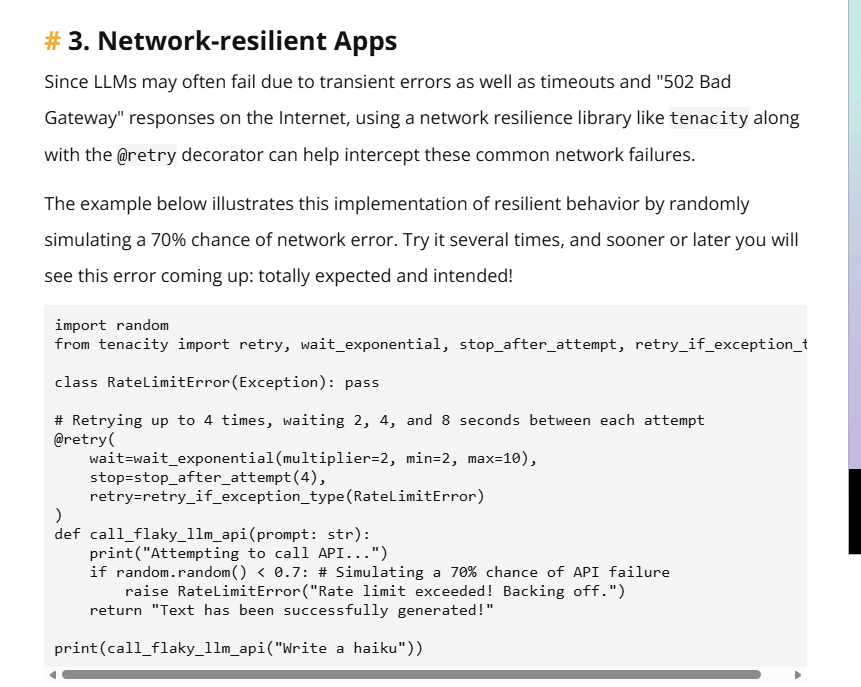

In [10]:
!pip install tenacity

  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
Using cached tenacity-9.1.4-py3-none-any.whl (28 kB)


In [11]:
import random
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

class RateLimitError(Exception): pass

# Retrying up to 4 times, waiting 2, 4, and 8 seconds between each attempt
@retry(
    wait=wait_exponential(multiplier=2, min=2, max=10),
    stop=stop_after_attempt(4),
    retry=retry_if_exception_type(RateLimitError)
)
def call_flaky_llm_api(prompt: str):
    print("Attempting to call API...")
    if random.random() < 0.7: # Simulating a 70% chance of API failure
        raise RateLimitError("Rate limit exceeded! Backing off.")
    return "Text has been successfully generated!"

print(call_flaky_llm_api("Write a haiku"))

Attempting to call API...
Attempting to call API...
Attempting to call API...
Attempting to call API...
Text has been successfully generated!


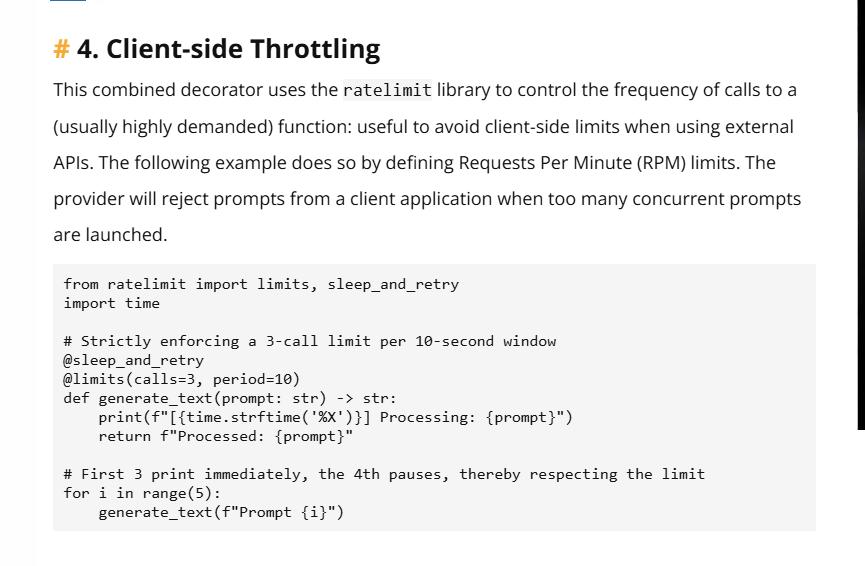

In [13]:
!pip install ratelimit

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ratelimit: filename=ratelimit-2.2.1-py3-none-any.whl size=5971 sha256=e1d27fed26afee2368186e0db37f66d22480255c5944c388f502a34bcec41f54
  Stored in directory: /home/codespace/.cache/pip/wheels/69/bd/e0/4a5dee2a1bfbc8e258f543f92940e2b494d63b5be8144ec8c4
Successfully built ratelimit


In [14]:
from ratelimit import limits, sleep_and_retry
import time

# Strictly enforcing a 3-call limit per 10-second window
@sleep_and_retry
@limits(calls=3, period=10)
def generate_text(prompt: str) -> str:
    print(f"[{time.strftime('%X')}] Processing: {prompt}")
    return f"Processed: {prompt}"

# First 3 print immediately, the 4th pauses, thereby respecting the limit
for i in range(5):
    generate_text(f"Prompt {i}")

[16:52:52] Processing: Prompt 0
[16:52:52] Processing: Prompt 1
[16:52:52] Processing: Prompt 2
[16:53:02] Processing: Prompt 3
[16:53:02] Processing: Prompt 4


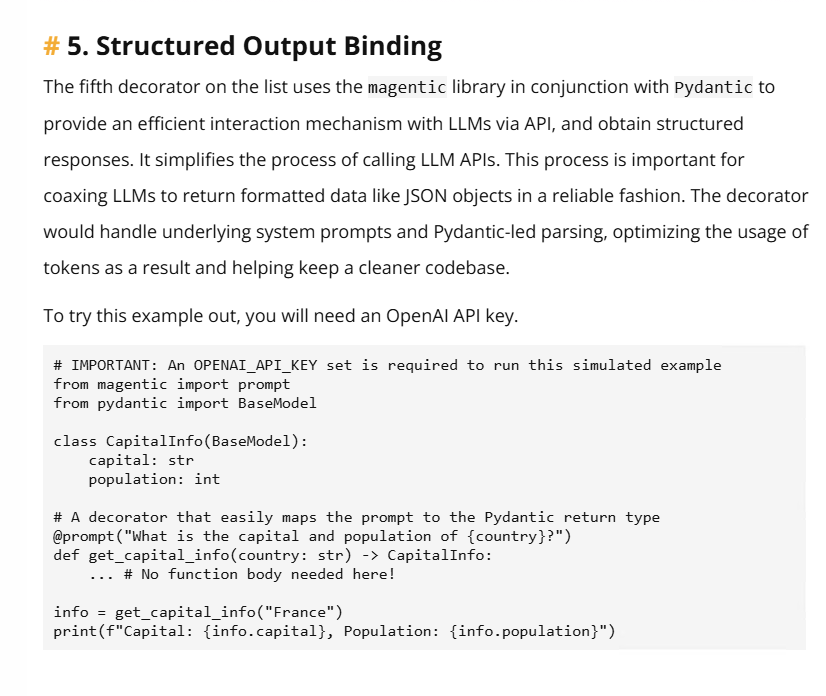

In [19]:
!pip install magentic

  Using cached pydantic_settings-2.13.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.0 MB/s  0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached pydantic_settings-2.13.1-py3-none-any.whl (58 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [magentic]8/9 [magentic]


In [17]:
!pip install pydantic

  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.1 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pydantic]3/4 [pydantic]


In [20]:
# IMPORTANT: An OPENAI_API_KEY set is required to run this simulated example
from magentic import prompt
from pydantic import BaseModel

class CapitalInfo(BaseModel):
    capital: str
    population: int

# A decorator that easily maps the prompt to the Pydantic return type
@prompt("What is the capital and population of {country}?")
def get_capital_info(country: str) -> CapitalInfo:
    ... # No function body needed here!

info = get_capital_info("France")
print(f"Capital: {info.capital}, Population: {info.population}")

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable